In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Orders Exploration

In [2]:
df_orders = pd.read_csv('../data/orders.csv')

In [3]:
df_orders.shape

(32313, 8)

In [6]:
df_orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [4]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  str    
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), str(1)
memory usage: 2.0 MB


In [5]:
df_orders.isna().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [8]:
df_orders['created_at'] = pd.to_datetime(df_orders['created_at'])

In [9]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            32313 non-null  int64         
 1   created_at          32313 non-null  datetime64[us]
 2   website_session_id  32313 non-null  int64         
 3   user_id             32313 non-null  int64         
 4   primary_product_id  32313 non-null  int64         
 5   items_purchased     32313 non-null  int64         
 6   price_usd           32313 non-null  float64       
 7   cogs_usd            32313 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(5)
memory usage: 2.0 MB


In [37]:
df_orders['order_id'].nunique()

32313

In [38]:
df_orders['user_id'].nunique()

31696

In [56]:
df_orders['order_id'].nunique() - df_orders['user_id'].nunique()

617

In [40]:
df_orders[['items_purchased', 'price_usd', 'cogs_usd']].describe()

,items_purchased,price_usd,cogs_usd
count,32313.000000,32313.000000,32313.000000
mean,1.238666,59.991636,22.355406
std,0.426274,17.808771,6.238621
min,1.000000,29.990000,9.490000
25%,1.000000,49.990000,19.490000
50%,1.000000,49.990000,19.490000
75%,1.000000,59.990000,22.490000
max,2.000000,109.980000,41.980000


In [50]:
df_orders['created_at'].describe()

count                         32313
mean     2014-04-14 03:01:01.276823
min             2012-03-19 10:42:46
25%             2013-10-30 14:30:35
50%             2014-06-11 14:27:02
75%             2014-11-28 10:53:48
max             2015-03-19 05:38:31
Name: created_at, dtype: object

In [53]:
df_orders['created_at'].dt.year.value_counts()

created_at
2014    16860
2013     7447
2015     5420
2012     2586
Name: count, dtype: int64

In [54]:
df_orders['created_at'].dt.month.value_counts()

created_at
12    3867
2     3587
1     3470
11    3464
3     2765
10    2688
9     2340
8     2161
7     2059
5     2047
6     1972
4     1893
Name: count, dtype: int64

In [55]:
df_orders['website_session_id'].nunique()

32313

In [57]:
df_orders['primary_product_id'].value_counts()

primary_product_id
1    23861
2     4803
3     3068
4      581
Name: count, dtype: int64

#### Column Insights
##### Order ID
- There are 32,313 orders
- Each row corresponds to a single order
##### Created At
- The earliest order was on March 19th, 2012, 10:42 AM
- The most recent order was on March 19th, 2015, 5:38 AM
- Most orders were in 2014, and the fewest orders were in 2012.
- The most common months orders were placed in were November - Feburary.
##### Website Session ID
- There are 32,313 session IDs
- Each row corresponds to a single session
##### User ID
- There are 31,696 unique customers
- 32,313 - 31,696 is 617, so 617 customers have multiple orders
##### Primary Product ID
- This column corresponds to the products table.
- The most commonly purchased item is with product ID 1.
    - Product ID 4 is the least commonly ordered.
##### Items Purchased
- The most items a user purchased in a single order is 2.
- More commonly, customers would only purchase one item.
##### Price USD
- The average price of the order was around 60 USD.
- The median price is around 50 USD, signifying that the distribution is right-skewed.
- The lowest price of an order was 30 USD and the highest was 110 USD

<Axes: xlabel='price_usd', ylabel='Count'>

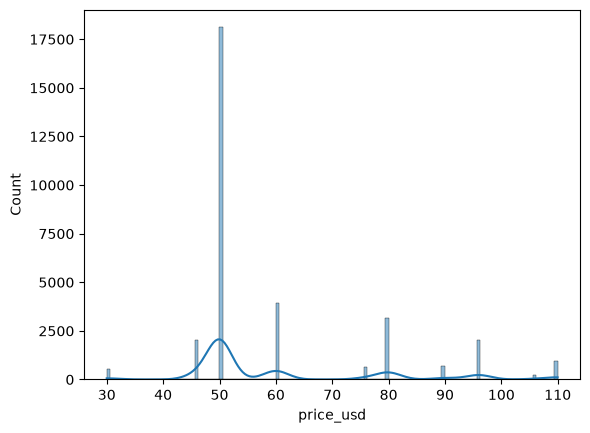

In [42]:
sns.histplot(data=df_orders['price_usd'], kde=True)

<Axes: ylabel='price_usd'>

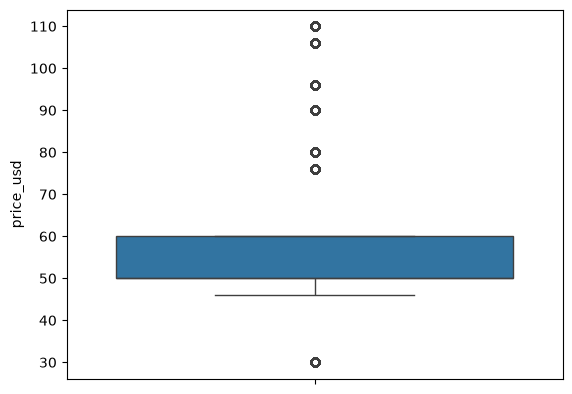

In [43]:
sns.boxplot(data=df_orders['price_usd'])

In [48]:
df_orders['items_purchased'].value_counts()

items_purchased
1    24601
2     7712
Name: count, dtype: int64

In [49]:
df_orders['items_purchased'].value_counts(normalize=True)

items_purchased
1    0.761334
2    0.238666
Name: proportion, dtype: float64

## Order Items Exploration

In [10]:
df_order_items = pd.read_csv('../data/order_items.csv')

In [11]:
df_order_items.shape

(40025, 7)

In [12]:
df_order_items.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [13]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  str    
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), str(1)
memory usage: 2.1 MB


In [14]:
df_order_items.isna().sum()

order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

In [15]:
df_order_items['created_at'] = pd.to_datetime(df_order_items['created_at'])

In [16]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[us]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(4)
memory usage: 2.1 MB


## Products Exploration

In [17]:
df_products = pd.read_csv('../data/products.csv')

In [19]:
df_products.shape

(4, 3)

In [20]:
df_products.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [23]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    4 non-null      int64         
 1   created_at    4 non-null      datetime64[us]
 2   product_name  4 non-null      str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 228.0 bytes


In [22]:
df_products['created_at'] = pd.to_datetime(df_products['created_at'])

In [24]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    4 non-null      int64         
 1   created_at    4 non-null      datetime64[us]
 2   product_name  4 non-null      str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 228.0 bytes


## Website Pageview Exploration|

In [25]:
df_page_view = pd.read_csv('../data/website_pageviews.csv')

In [26]:
df_page_view.shape

(1188124, 4)

In [27]:
df_page_view.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


In [28]:
df_page_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   website_pageview_id  1188124 non-null  int64
 1   created_at           1188124 non-null  str  
 2   website_session_id   1188124 non-null  int64
 3   pageview_url         1188124 non-null  str  
dtypes: int64(2), str(2)
memory usage: 36.3 MB


In [29]:
df_page_view['created_at'] = pd.to_datetime(df_page_view['created_at'])

In [30]:
df_page_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   website_pageview_id  1188124 non-null  int64         
 1   created_at           1188124 non-null  datetime64[us]
 2   website_session_id   1188124 non-null  int64         
 3   pageview_url         1188124 non-null  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 36.3 MB


## Website Sessions Exploration

In [31]:
df_sessions = pd.read_csv('../data/website_sessions.csv')

In [32]:
df_sessions.shape

(472871, 9)

In [33]:
df_sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [34]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   website_session_id  472871 non-null  int64
 1   created_at          472871 non-null  str  
 2   user_id             472871 non-null  int64
 3   is_repeat_session   472871 non-null  int64
 4   utm_source          389543 non-null  str  
 5   utm_campaign        389543 non-null  str  
 6   utm_content         389543 non-null  str  
 7   device_type         472871 non-null  str  
 8   http_referer        432954 non-null  str  
dtypes: int64(3), str(6)
memory usage: 32.5 MB


In [35]:
df_sessions['created_at'] = pd.to_datetime(df_sessions['created_at'])

In [36]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   website_session_id  472871 non-null  int64         
 1   created_at          472871 non-null  datetime64[us]
 2   user_id             472871 non-null  int64         
 3   is_repeat_session   472871 non-null  int64         
 4   utm_source          389543 non-null  str           
 5   utm_campaign        389543 non-null  str           
 6   utm_content         389543 non-null  str           
 7   device_type         472871 non-null  str           
 8   http_referer        432954 non-null  str           
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 32.5 MB


In [47]:
df_page_view['pageview_url'].value_counts()

pageview_url
/products                      261231
/the-original-mr-fuzzy         162525
/home                          137576
/lander-2                      131170
/cart                           94953
/lander-3                       79000
/lander-5                       68166
/shipping                       64484
/billing-2                      48441
/lander-1                       47574
/thank-you-for-your-order       32313
/the-forever-love-bear          26033
/the-birthday-sugar-panda       19046
/lander-4                        9385
/billing                         3617
/the-hudson-river-mini-bear      2610
Name: count, dtype: int64